<a href="https://colab.research.google.com/github/Lokeshanthagiri/capgemini/blob/main/Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   TransactionID  Amount  Time   Location  Merchant DeviceType  Fraud
0              1   78325     9    Chennai  Flipkart     Mobile      0
1              2   10337    18  Hyderabad     Paytm     Tablet      0
2              3   53189    19    Chennai    Amazon     Tablet      0
3              4   22970    22      Delhi   Unknown     Tablet      0
4              5   13444    22      Delhi   Unknown     Tablet      0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   TransactionID  1000 non-null   int64 
 1   Amount         1000 non-null   int64 
 2   Time           1000 non-null   int64 
 3   Location       1000 non-null   object
 4   Merchant       1000 non-null   object
 5   DeviceType     1000 non-null   object
 6   Fraud          1000 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 54.8+ KB
None
TransactionID    0
Amount       

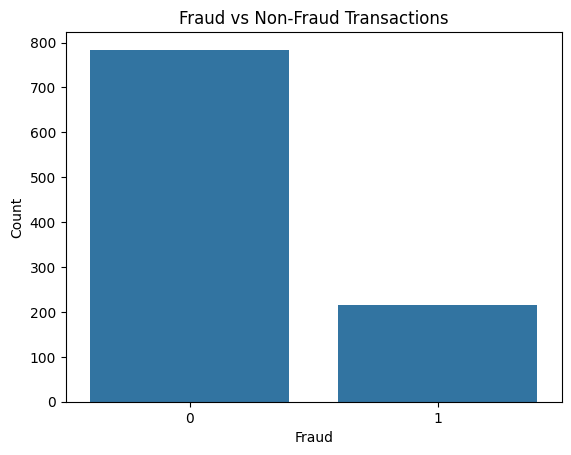


Fraud Transaction Detected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Model
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load Dataset
df = pd.read_csv("/content/fraud_detection_dataset.csv")

# Display First 5 Rows
print(df.head())

# Dataset Information
print(df.info())

# Check Missing Values
print(df.isnull().sum())

# Encode Categorical Columns
le = LabelEncoder()

df["Location"] = le.fit_transform(df["Location"])
df["Merchant"] = le.fit_transform(df["Merchant"])
df["DeviceType"] = le.fit_transform(df["DeviceType"])

# Features and Target
X = df.drop(["Fraud", "TransactionID"], axis=1)

y = df["Fraud"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = RandomForestClassifier()

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# Fraud Count Visualization
sns.countplot(x=df["Fraud"])

plt.title("Fraud vs Non-Fraud Transactions")

plt.xlabel("Fraud")

plt.ylabel("Count")

plt.show()

# Predict New Transaction
# Format:
# [Amount, Time, Location, Merchant, DeviceType]

new_transaction = [[75000, 2, 1, 4, 0]]

prediction = model.predict(new_transaction)

if prediction[0] == 1:
    print("\nFraud Transaction Detected")
else:
    print("\nLegitimate Transaction")